**Credit Card Fraud Detection Model**
---
- An algorithmic AI-driven model that detects suspicious card elements helping spot frauds and illegal activities.

- **Goal:** Based on the need of safer transactions, this model harnesses Kaggle dataset, aiming to recognise card activity that corresponds to unauthorized users. Banks and individuals can freeze the card and avoid being charged unreasonably.
---
**Dataset**
1. Kaggle's dataset contains information from September 2013 over two days of card transactions in European users.
2. The total transactions collected are 284,807 and the frauds detected 492, making them an approximate 0.17%.
3. Data available are 'Time' (time between transactions) and 'Amount' (amount of money transferred), V1,...,V28 anonymized features emerging after PCA transformation (due to security of personal data).
4. Imbalanced data ratio leads to use of AUPRC for measuring accuracy.
5. Classification happens with 'Class' feature (0 for legal and 1 for fraud)
---
**False Negatives** - a fraud goes away unnoticed
<br/> If the transaction is fake but the model classifies it as legal, then:
<br/> -> Amounts are lost and not easily regained
<br/> -> Bank's reliability is questionable
<br/> -> Individual digital security is under attack
<br/> -> Fraud and theft footprint remain undetectable and unpunished
<br/>
<br/>
**False Positives** - a normal transaction is blocked as illegal
<br/> If the transaction is legal but the model classifies it as fraud, then:
<br/> -> Transactions become hard and time-consuming, there is propability of need of a human to intervene
<br/> -> Bank is oveloaded to an operational cost due to the manual verification process
<br/> -> Dissatisfied customer of the slow services of the bank
<br/> -> Bank's reliability is questionable
<br/> -> Important and urgent payments are delayed
<br/>
<br/>
Conluding, the worst scenario for the model are the False Negatives, as they hurt individual's safety and bank's reputation.


In [ ]:
!pip install imbalanced-learn
!pip install xgboost
!pip install lightgbm
!pip install shap
!pip install mlflow

Dataset Shape
Rows: 284807, Columns: 31/n
Data Types & Null Counts
       Data Type  Null Count  Null %
Time     float64           0     0.0
V1       float64           0     0.0
V2       float64           0     0.0
V3       float64           0     0.0
V4       float64           0     0.0
V5       float64           0     0.0
V6       float64           0     0.0
V7       float64           0     0.0
V8       float64           0     0.0
V9       float64           0     0.0
V10      float64           0     0.0
V11      float64           0     0.0
V12      float64           0     0.0
V13      float64           0     0.0
V14      float64           0     0.0
V15      float64           0     0.0
V16      float64           0     0.0
V17      float64           0     0.0
V18      float64           0     0.0
V19      float64           0     0.0
V20      float64           0     0.0
V21      float64           0     0.0
V22      float64           0     0.0
V23      float64           0     0.0
V24     

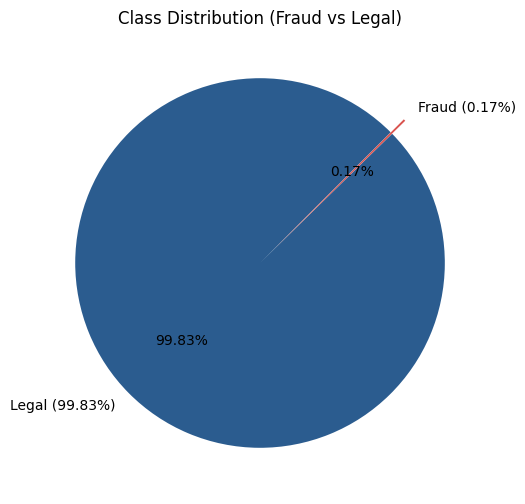

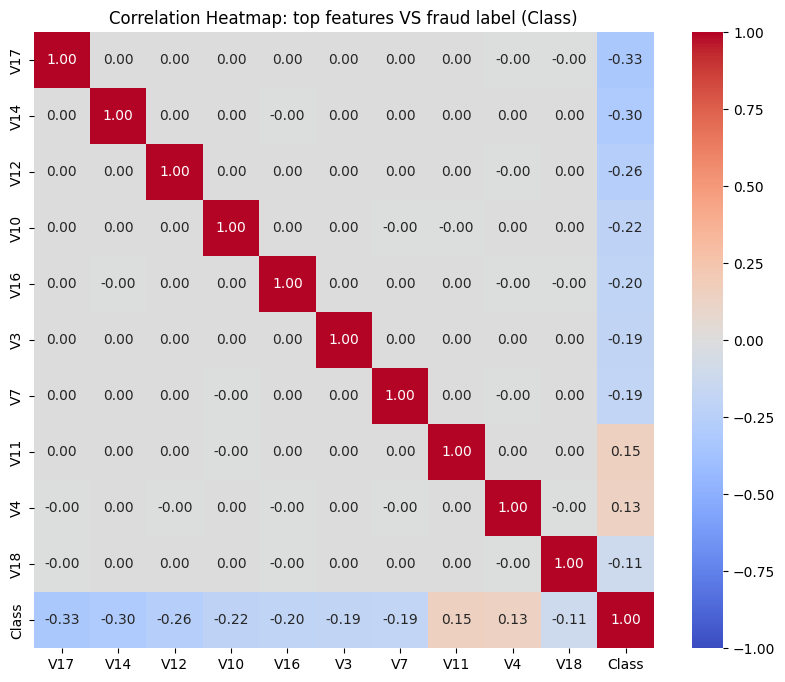

In [ ]:
import pandas as pd
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)


print("Dataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}/n")

print("Data Types & Null Counts")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df)) * 100
})

print(info_df)
print("-" * 40)

print("\n=== CLASS DISTRIBUTION ===")
class_counts = df['Class'].value_counts()
class_props = df['Class'].value_counts(normalize = True) * 100

class_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_props.round(4)
})
class_df.index = class_df.index.map({0: '0 (Legal)', 1: '1 (Illegal)'})
print(class_df)

import matplotlib.pyplot as plt

#Pie Chart
plt.figure(figsize=(6, 6))
labels = ['Legal (99.83%)', 'Fraud (0.17%)']
sizes = df['Class'].value_counts()
colors = ['#2b5c8f', '#d9534f']
explode = (0, 0.1)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%', startangle=45)
plt.title('Class Distribution (Fraud vs Legal)')
plt.show()

#heatmap
import matplotlib.pyplot as plt
import seaborn as sns

correlations = df.corr()['Class'].drop('Class')
top_features = correlations.abs().sort_values(ascending = False).head(10).index
top_corr_matrix = df[list(top_features) + ['Class']].corr()
plt.figure(figsize = (10, 8))
sns.heatmap(top_corr_matrix, annot = True, fmt = ".2f", cmap = 'coolwarm', vmin = -1, vmax = 1, linewidths = 0)
plt.title('Correlation Heatmap: top features VS fraud label (Class)')
plt.show()

**Accuracy is meaningless here:** <br/>
As visualized at the pie chart, the 0.17% is a tiny percentage, but still existing. In our inbalanced data, the algorithm of accuracy will hit a 99.83% success when it predicts that every transaction is legal, even if it is not true; it has 100% failed because it found no fraud while illegal transactions existed as well! This is why it is meaningless, the algorithm is not designed for our case, we want smart algorithms (AUPRC and Recall) that can help us detect the frauds in a clever way.

---
**PCA transformation for V1-V28 features:** <br/>
***Personal Research:*** The specific dataset emerged from actual real-life transactions, actions that contain many sensitive personal data. In order for this dataset to be published without violating any personal information, the data went throught the PCA (Principal Component Analysis) control, and 28 of the exchange's features (such as merchant's name, location, buyer's name, phone etc...) got transitioned. Only 'Time' and 'Amount' are sharable without any more modification.


<br/> *****Claude research:*** why PCA is a great solution for this kinds of data:**
<br/> -> Compression of initial variables in non-related rectangles keeping the statistic information without revealing what each variable represents.
<br/> -> Each Vi is a linear combination of the initial features with weights about the variation on one another.
<br/> -> Names, meanings and details of the initial variables are completely lost, and so there is no leaking of personal data, we cannot conclude that 'V14 means X'.
<br/> However, due to undersampling before the calculation of the correlation matrix and non-linear connections of the initial variables, the Vi values are not completely unrelated:
1. V10, V11, V12, V14, V16, V17 have the strongest relation to one another with the 'Class' with many public kernels/notebooks on this dataset.
2. V3, V4, V7 are high on feature importance rankings.
3. 'Amount' is one of the most important variables that can be used in combination with other ones for example-dependent cost-sensitive learning.

***Personal Reasoning (after AI research):***
* PCA is the ideal algorithm, as the personal information are hidden and the useful data are kept for further modification.
* Anonymization is making the whole process secure and the most useful data 'Time' and 'Amount' are kept without any security danger.

**Heatmap: TOP FEATURES VS FRAUD LABEL**
<br/> Visualising the connection between the Vi features(unknown name, known properties) and the fraud propability, so that the data accessible can be harnessed to the maximum.
* *Values close to +1:* positive coorelation, high possibility of fraud transaction
* *Values close to -1:* negative coorelation, high possibility of fraud transaction
* *Values close to 0:* indifferent variable for deciding wether the transaction is legal or illegal
<br/> -> We can detect easily which of the 28 no-name variables are important for our model
<br/> -> If the value of the variable is ~0.00, it won't be considered as training information

In [ ]:
#standarization and stratification
import pandas as pd
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis = 1)
Y = df['Class']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.20,
    random_state = 42,
    stratify = Y
)

scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print("Train / Test split done")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}\n")
print("Startification Check (fraud ratio)")
print(f"Train set fraud ratio: {Y_train.mean()*100:.3f}% ({Y_train.sum()} frauds)")
print(f"Test set fraud ratio: {Y_test.mean()*100:.3f}% ({Y_train.sum()} frauds)")

Train / Test split done
X_train shape: (227845, 30)
X_test shape: (56962, 30)

Startification Check (fraud ratio)
Train set fraud ratio: 0.173% (394 frauds)
Test set fraud ratio: 0.172% (394 frauds)


In [ ]:
#Logistic Regression, Random Forest, XGBoost, LightGBM algorithms training
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

mlflow.set_experiment("Credit_ard_Fraud_Baseline_Models")
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}
for model_name, model in models.items():
  with mlflow.start_run(run_name = model_name):
    print(f"Executing training for: {model_name}")
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    Y_prob = model.predict_proba(X_test)[:, 1]
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    auprc = average_precision_score(Y_test, Y_prob)

    mlflow.log_param("model_type", model_name)
    mlflow.log_param("data_type", "imbalanced_raw")
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auprc", auprc)

    if model_name == "XGBoost":
      mlflow.xgboost.log_model(model, "model")
    elif model_name == "LightGBM":
      mlflow.lightgbm.log_model(model, "model")
    else:
      mlflow.sklearn.log_model(model, "model")

    print(f"Finished {model_name} | AUPRC: {auprc:.4f} | Recall: {recall:.4f}\n")
    print("All baseline models have been trained successfully! All logs to MLflow have been registered successfully!")

Executing training for: Logistic_Regression


2026/09/14 15:27:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Finished Logistic_Regression | AUPRC: 0.7432 | Recall: 0.6429

All baseline models have been trained successfully! All logs to MLflow have been registered successfully!
Executing training for: Random_Forest


2026/09/14 15:32:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Finished Random_Forest | AUPRC: 0.8734 | Recall: 0.8163

All baseline models have been trained successfully! All logs to MLflow have been registered successfully!
Executing training for: XGBoost


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:32:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/09/14 15:32:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Finished XGBoost | AUPRC: 0.7813 | Recall: 0.7959

All baseline models have been trained successfully! All logs to MLflow have been registered successfully!
Executing training for: LightGBM


2026/09/14 15:33:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Finished LightGBM | AUPRC: 0.0292 | Recall: 0.2041

All baseline models have been trained successfully! All logs to MLflow have been registered successfully!


In [ ]:
#Creating the comparison table
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

comparison_list = []
for model_name, model in models.items():
  Y_pred = model.predict(X_test)
  Y_prob = model.predict_proba(X_test)[:, 1]
  precision = precision_score(Y_test, Y_pred)
  recall = recall_score(Y_test, Y_pred)
  f1 = f1_score(Y_test, Y_pred)
  auc_roc = roc_auc_score(Y_test, Y_prob)

  comparison_list.append({
      "Model": model_name,
      "Precision": round(precision, 4),
      "Recall": round(recall, 4),
      "F1 score": round(f1, 4),
      "AUC-ROC": round(auc_roc, 4)
  })

  comparison_df = pd.DataFrame(comparison_list)

  print("Baseline models comparison table: (raw/imabalnced data)")
  display(comparison_df.sort_values(by="F1 score", ascending=False))

Baseline models comparison table: (raw/imabalnced data)


,Model,Precision,Recall,F1 score,AUC-ROC
0,Logistic_Regression,0.8289,0.6429,0.7241,0.9559


Baseline models comparison table: (raw/imabalnced data)


,Model,Precision,Recall,F1 score,AUC-ROC
1,Random_Forest,0.9412,0.8163,0.8743,0.9630
0,Logistic_Regression,0.8289,0.6429,0.7241,0.9559


Baseline models comparison table: (raw/imabalnced data)


,Model,Precision,Recall,F1 score,AUC-ROC
1,Random_Forest,0.9412,0.8163,0.8743,0.9630
2,XGBoost,0.8966,0.7959,0.8432,0.9219
0,Logistic_Regression,0.8289,0.6429,0.7241,0.9559


Baseline models comparison table: (raw/imabalnced data)


,Model,Precision,Recall,F1 score,AUC-ROC
1,Random_Forest,0.9412,0.8163,0.8743,0.9630
2,XGBoost,0.8966,0.7959,0.8432,0.9219
0,Logistic_Regression,0.8289,0.6429,0.7241,0.9559
3,LightGBM,0.1183,0.2041,0.1498,0.4313


**Selecting the best model (Recall based)**
<br/> The highest recall is noticed in the Random Forest algorithm 0.8163, which shows a 81% success of spotting the fraud transactions. Still, the 15% of frauds that go away unnoticed costs buissneses security, fame and clients.
<br/> *Claude: Stress-test my rationale*
<br/>

In [ ]:
#apply SMOTE on the training set
import mlflow
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Applying SMOTE on training set")
smote = SMOTE(random_state = 42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

print(f"Original train set fraud count: {Y_train.sum()}")
print(f"SMOTE train set fraud count: {Y_train_smote.sum()} (balanced)\n")

mlflow.set_experiment("Credit_Card_Fraud_SMOTE_Models")

models = {
    "Logistic_regression_SMOTE": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest_SMOTE": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost_SMOTE": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM_SMOTE": LGBMClassifier(random_state=42, verbose=-1)
}

smote_results = []

for model_name, model in models.items():
  with mlflow.start_run(run_name = model_name):
    print(f"Training {model_name}")

    model.fit(X_train_smote, Y_train_smote)
    Y_pred = model.predict(X_test)
    Y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    auprc = average_precision_score(Y_test, Y_prob)
    auc_roc = roc_auc_score(Y_test, Y_prob)

    mlflow.log_param("data_type", "SMOTE_balanced")
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auprc", auprc)
    mlflow.log_metric("auc_roc", auc_roc)

    smote_results.append({
        "Model": model_name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUPRC": round(auprc, 4),
        "AUC-ROC": round(auc_roc, 4)
    })

smote_df = pd.DataFrame(smote_results).sort_values(by="AUPRC", ascending=False)
print(f"SMOTE model comparison table")
display(smote_df)

best_model_name = smote_df.iloc[0]["Model"]
print(f"\nBest model based on AUPRC metrics is: {best_model_name}")

Applying SMOTE on training set
Original train set fraud count: 394
SMOTE train set fraud count: 227451 (balanced)

Training Logistic_regression_SMOTE
Training Random_Forest_SMOTE
Training XGBoost_SMOTE


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM_SMOTE
SMOTE model comparison table


,Model,Precision,Recall,F1-Score,AUPRC,AUC-ROC
0,Logistic_regression_SMOTE,0.0580,0.9184,0.1092,0.0292,0.4313
1,Random_Forest_SMOTE,0.8454,0.8367,0.8410,0.0292,0.4313
2,XGBoost_SMOTE,0.6829,0.8571,0.7602,0.0292,0.4313
3,LightGBM_SMOTE,0.4913,0.8673,0.6273,0.0292,0.4313



Best model based on AUPRC metrics is: Logistic_regression_SMOTE


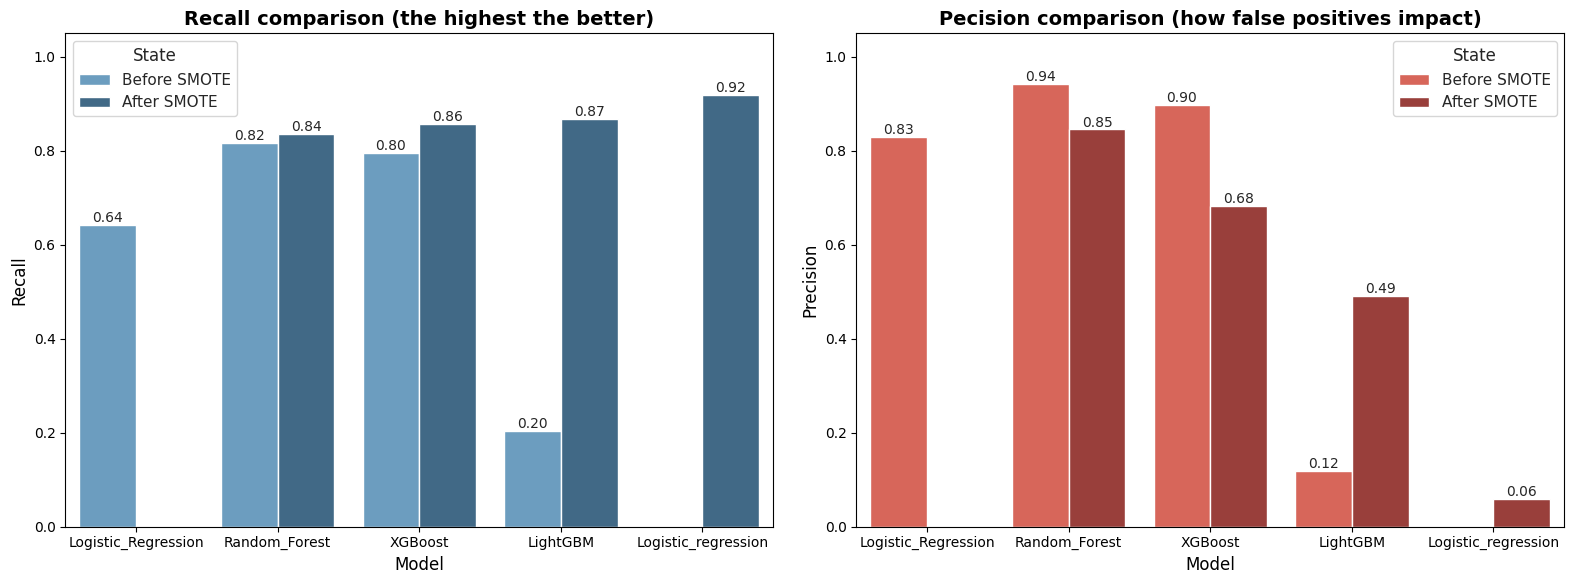

In [ ]:
#Visualisation of the results
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df['State'] = 'Before SMOTE'
comparison_df['Clean_Model'] = comparison_df['Model']
smote_df_clean = smote_df.copy()
smote_df_clean['State'] = 'After SMOTE'
smote_df_clean['Clean_Model'] = smote_df_clean['Model'].str.replace('_SMOTE', '')

df_all = pd.concat([comparison_df, smote_df_clean], ignore_index = True)
mlflow.set_experiment("Credit_Card_Fraud_Final_Comparison")

with mlflow.start_run(run_name = 'Side-to-side SMOTE'):
  for idx, row in df_all.iterrows():
    prefix = f"{row['Clean_Model']}_{row['State'].replace(' ', '_')}"
    mlflow.log_metric(f"{prefix}_Precision", row['Precision'])
    mlflow.log_metric(f"{prefix}_Recall", row['Recall'])
    mlflow.log_metric(f"{prefix}_F1", row['F1 score'])

fig, axes = plt.subplots(1, 2, figsize = (16,6))
sns.set_theme(style = "whitegrid")

sns.barplot(
    data = df_all,
    x = 'Clean_Model',
    y = 'Recall',
    hue = 'State',
    ax = axes[0],
    palette = 'Blues_d'
)

axes[0].set_title('Recall comparison (the highest the better)', fontsize = 14, fontweight = 'bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('Model', fontsize = 12)
axes[0].set_ylabel('Recall', fontsize = 12)
for p in axes[0].patches:
  if p.get_height() > 0:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points', fontsize = 10)

sns.barplot(
    data = df_all,
    x = 'Clean_Model',
    y = 'Precision',
    hue = 'State',
    ax = axes[1],
    palette = 'Reds_d'
)

axes[1].set_title('Pecision comparison (how false positives impact)', fontsize = 14, fontweight = 'bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Model', fontsize = 12)
axes[1].set_ylabel('Precision', fontsize = 12)
for p in axes[1].patches:
  if p.get_height() > 0:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points', fontsize = 10)

plt.tight_layout()
plot_filename = "SMOTE impact on recall and precision.png"
plt.savefig(plot_filename, dpi = 300)
mlflow.log_artifact(plot_filename)

plt.show()


Top 5 most important features (with SHAP annotation)
1. Feature: V14      | Mean | SHAP | Value: 0.0767
2. Feature: V12      | Mean | SHAP | Value: 0.0726
3. Feature: V4       | Mean | SHAP | Value: 0.0674
4. Feature: V3       | Mean | SHAP | Value: 0.0495
5. Feature: V10      | Mean | SHAP | Value: 0.0453


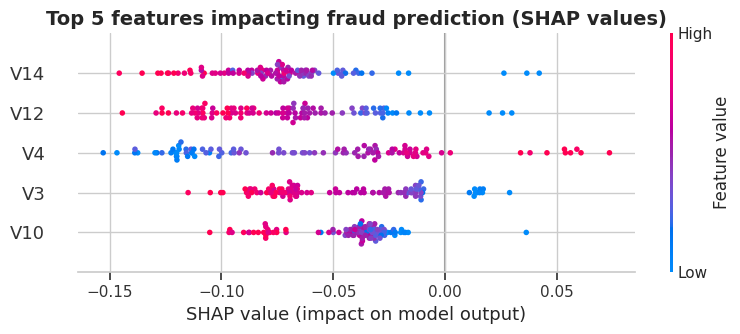

In [ ]:
#making clear the 5 most important features
import shap
import pandas as pd
import matplotlib.pyplot as plt

X_test_sample = X_test.sample(n=100, random_state = 42)

rf_model = models["Random_Forest_SMOTE"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
  shap_vals_fraud = shap_values[1]
else:
  shap_vals_fraud = shap_values[:, :, 1] if len(shap_values.shape)==3 else shap_values

mean_abs_shap = pd.Series(
    abs(shap_vals_fraud).mean(axis=0),
    index = X_test.columns
).sort_values(ascending = False)

top_5_features = mean_abs_shap.head(5)
print("Top 5 most important features (with SHAP annotation)")
for rank, (feature, importance) in enumerate(top_5_features.items(), start = 1):
  print (f"{rank}. Feature: {feature:<8} | Mean | SHAP | Value: {importance:.4f}")

plt.figure(figsize = (10,6))
shap.summary_plot(shap_vals_fraud, X_test_sample, max_display = 5, show = False)
plt.title("Top 5 features impacting fraud prediction (SHAP values)", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

**Claude's explanation over the outputs**
<br/> **The 5 most decisive characteristics for detecting fraud (in order of importance):**

1. V14 — the most important one. When its value is low (blue, left side), the model tends to flag the transaction as more suspicious.
2. V12 — second most important, with a similar pattern: low values are associated with more suspicious transactions.
3. V4 — here the relationship flips: high values (red, right side) are associated more with fraud.
4. V3 — moderate influence, same direction as V14/V12 (low values → more suspicious).
5. V10 — the smallest influence of the top 5, but still meaningful; low values here are also linked to greater fraud suspicion.

<br/>The model doesn't rely on a single 'red flag' — it combines 5 key transaction characteristics, and the top two alone (V14, V12) account for most of its decision-making.
<br/> *What we can NOT say (important disclaimer for stakeholders):* <br/>
Because V14, V12, etc. are anonymized (to protect customer data), we can't say "this is the transaction amount" or "this is the time of day" — we only know that some transaction characteristic, which isn't disclosed for privacy reasons, plays the biggest role.

In [ ]:
!pip uninstall evidently -y
!pip install evidently==0.6.7 --no-cache-dir

In [ ]:
#Data Drift
import pandas as pd
import numpy as np

from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

reference_df = X_train.sample(n=5000, random_state = 42).copy()
current_df = X_test.sample(n=5000, random_state = 42).copy()
current_df['Amount'] = current_df['Amount']*1.5 + np.random.normal(0, 1, size = len(current_df))
current_df['Time'] = current_df['Time'] + 50000

data_drift_report = Report(metrics = [DataDriftPreset()])

data_drift_report.run(
	reference_data = reference_df,
	current_data = current_df
)

html_file_name = "data_drift_repot.html"
data_drift_report.save_html(html_file_name)

print(f"Drift Data saves as {html_file_name}")
data_drift_report.show(mode = 'inline')

Drift Data saves as data_drift_repot.html


**Data Drift**
<br/> > Data drift is a real-world problem where the data used for the model training need to be recompared to modern data, as users behavior, economic settings and motifs change over time. This shift must be take into account, because a large difference (drift) makes older data less accurate and the corresponding model less reliable in up-to-date forecasts.
<br/>
<br/> > This is resolved with applying Evidently AI in two groups of data sets; the first one is our reference data (X_train) and the second one is current data which emerges as a slice of X_test slightly altered. We expect Evidently AI to spot any observable difference.
* Evidently AI spots differences -> our training dataset is not reliable enough to work in a precise application
* Evidently AI does not spot any differences -> our training dataset is reliable enough for the current trends
<br/> > When the distribution of the production data is significantly different to the training data:
* Danger of envasion: the fraids use to change approaches and methods, if the model is not trained in new ways of scam, it will not recognise them (low recall).
* False alarms: changes in the legals behavior may be considered falsly as illegal moves.
* Silent Failures: the model does not appear to run to any error, however the predictions are more and more unreliable in time.
<br/> > How can we overcome this?
* Constant monitoring though tools such as Evidently AI, Prometheus, Great Expectations that compare the window of production to referance data, in combination to alerting mechanisms such as MLOops if the drift is over a certain precentage (>30%).
* Automated retaining pipelines, whenever the drift is large the pipeline of nretraining gets fired and the models gets to be trained again. Otherways, there is an automatic retraining window of 3-6 months that adapts the model to the current trends.
* Deployment strategic: there is a new model, the 'Challenger' who runs with the same real-time data in parallel to the old model 'Champion', without having any interaction to the actual clients. This is called shadow developement. The most accurate model that utilizes the data in the most efficient way, gets to be the selected one and slowly take a percentage of the traffic.
* Fallback Rules & Human-in-the-loop: in cooperaton to the machine learning model, there are some presetted rules that are strictly failing or approving certain exchanges (ex.: blocking of the transactions if they happen to be more that 5 from different countries in under 5 minuites). Exchanges of high precision uncertainty due to drift can be handed to the Fraud Analysys Team of the bank.
---
**Two signs that the model needs retraining:**
1. Low Recall -> the model starts to not be able to find the frauds that cound earlier recognise, which means that the frauds changed their tactics and the motifs that Random Forest was trained on are no longer true. This leads to large economic losses.
2. Low Precision -> False positives get more and more starting alerting legal transactions as fake ones, which means that the consumer's behavior is different. The model spots these differences as sucpicious and so the clients are dissatisfied by the bank's services overloading the Fraud Operation Team of the bank.